# Sleep prediction — scratchpad

Predict, from any awake moment, whether the baby falls asleep in the next 30 minutes.

- **Data:** `ml.ml_sleep_training_set`, read from a local parquet snapshot under `ml/data/`. The first run pulls one over the SSH tunnel (`ssh -N fedora-1-db`); after that it's offline. `load_training_set(refresh=True)` pulls a fresh one.
- **Split:** `split_forward_time`. Tune against `val`; leave `test` alone until the final comparison.
- **Base rate drifts** from ~33% in train to ~20% in test (older baby, longer wake windows), so always read PR-AUC next to the base rate.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd

from baby_ml import (
    Comparison,
    FeatureSpec,
    Predictions,
    load_training_set,
    metrics_table,
    plot_feature_importance,
    plot_performance,
    plot_shap_summary,
    recall_at_percentiles,
    train,
)

C:\Users\nikil\dbt-baby-data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = load_training_set()
print(df.attrs["snapshot"], df.shape)
df.head()

ml_sleep_training_set_20260923T211259.parquet (28713, 63)


,prediction_id,baby_id,baby_name,prediction_time,calendar_date,is_asleep_30_mins,is_asleep_60_mins,minutes_to_next_sleep,split_forward_time,split_random_day,...,feed_minutes_last_3h,feed_minutes_last_24h,avg_feed_interval_last_24h,is_cluster_feeding,minutes_since_last_diaper_change,minutes_since_last_dirty_diaper,had_dirty_diaper_last_60_mins,diaper_count_last_6h,diaper_count_last_24h,dirty_diaper_count_last_24h
0,fd1f8730c98f12012ae594ae250088e7,3d6aea57-9fdc-5ccd-abaf-02bf7ab8bbfe,Ember,2023-09-14 03:40:00,2023-09-14,1,1,26,train,val,...,14,247,118.0,False,2,376,False,2,10,7
1,c73142e023669411f92148330453dd08,3d6aea57-9fdc-5ccd-abaf-02bf7ab8bbfe,Ember,2023-09-14 03:50:00,2023-09-14,1,1,16,train,val,...,14,247,118.0,False,12,386,False,2,10,7
2,3c8ebbd652cce988ab5a24e81355ef8e,3d6aea57-9fdc-5ccd-abaf-02bf7ab8bbfe,Ember,2023-09-14 04:00:00,2023-09-14,1,1,6,train,val,...,35,268,110.0,False,22,396,False,2,10,7
3,a2626eb515510323049537afabab4174,3d6aea57-9fdc-5ccd-abaf-02bf7ab8bbfe,Ember,2023-09-14 06:10:00,2023-09-14,0,1,60,train,val,...,35,224,104.0,False,152,526,False,2,10,7
4,e621eec98c2645e1a6ec28d3f5f77267,3d6aea57-9fdc-5ccd-abaf-02bf7ab8bbfe,Ember,2023-09-14 06:20:00,2023-09-14,0,1,50,train,val,...,21,224,104.0,False,162,536,False,2,10,7


## Base rate by split and baby

In [3]:
(
    df.groupby(["split_forward_time", "baby_name"], observed=True)
    .agg(rows=("prediction_id", "size"),
         asleep_30=("is_asleep_30_mins", "mean"),
         asleep_60=("is_asleep_60_mins", "mean"),
         age_weeks_min=("age_weeks", "min"),
         age_weeks_max=("age_weeks", "max"))
    .round(3)
)

rows  asleep_30  asleep_60  age_weeks_min  \
split_forward_time baby_name                                               
test               Ember       2450      0.180      0.360             44   
                   Imogen      1782      0.235      0.443             23   
train              Ember      12696      0.315      0.571              3   
                   Imogen      7395      0.359      0.655              0   
val                Ember       2599      0.193      0.382             37   
                   Imogen      1791      0.265      0.489             19   

                              age_weeks_max  
split_forward_time baby_name                 
test               Ember                 52  
                   Imogen                26  
train              Ember                 37  
                   Imogen                18  
val                Ember                 44  
                   Imogen                22

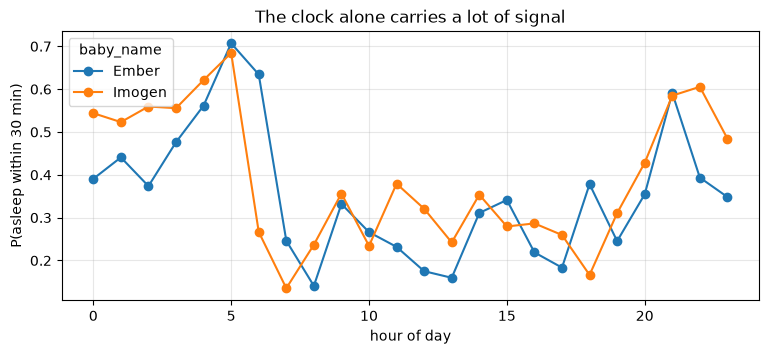

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.5))
(
    df.groupby(["hour_of_day", "baby_name"], observed=True)["is_asleep_30_mins"]
    .mean().unstack().plot(ax=ax, marker="o")
)
ax.set(xlabel="hour of day", ylabel="P(asleep within 30 min)", title="The clock alone carries a lot of signal")
ax.grid(alpha=0.3)

## Features

`FeatureSpec` decides what a model sees. Everything that isn't identity, label or split is a feature, so new dbt columns turn up automatically. Toggle `include_baby_name`, `exclude`, `label` or `split_column` to change the experiment.

In [5]:
spec = FeatureSpec()
X_train, y_train = spec.xy(df, "train")
X_val, y_val = spec.xy(df, "val")
print(f"{X_train.shape[1]} features; categorical: {spec.categorical_columns(df)}")
spec

52 features; categorical: ['last_feed_type', 'last_feed_breast_side']


FeatureSpec(label='is_asleep_30_mins', split_column='split_forward_time', include_baby_name=False, exclude=frozenset())

## One model, end to end

`train` fits any of `"lightgbm"`, `"xgboost"` or `"random_forest"` on the spec's train split, and everything below works the same for all three. Change `kind` and rerun. No tuning or calibration yet.

In [6]:
kind = "lightgbm"
model = train(kind, df, spec)
pred = Predictions.from_model(model, df, "val")
metrics_table([pred]).round(3)

,,split,rows,base_rate,pr_auc,roc_auc,brier,brier_base_rate,mean_predicted
label,model,,,,,,,,
is_asleep_30_mins,lightgbm,val,4390,0.222,0.567,0.85,0.138,0.173,0.311


### PR, ROC and cumulative recall

Cumulative recall ranks the rows by predicted probability and asks what share of all the real sleeps are caught by flagging the top x%. The dotted line is a perfect model: it catches everything by the time x reaches the base rate.

,,top 5%,top 10%,top 20%,top 30%,top 50%
label,model,,,,,
is_asleep_30_mins,lightgbm,0.137,0.275,0.519,0.703,0.921


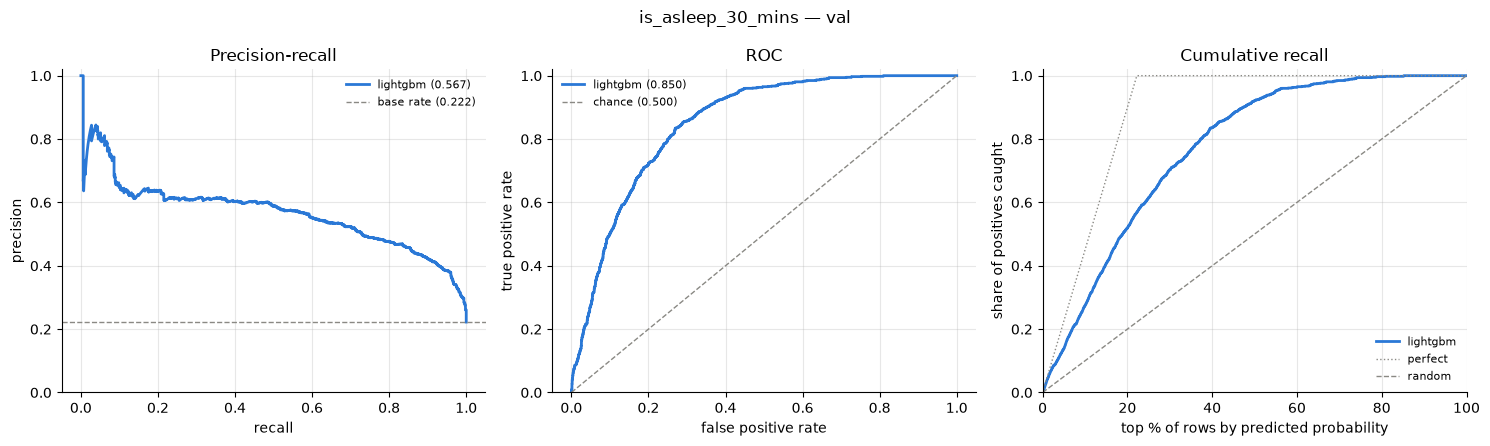

In [7]:
plot_performance([pred]);
recall_at_percentiles([pred]).round(3)

### Feature importance

Native importance (gain for the boosters, impurity for the forest) favours features with many split points, so read it next to SHAP, which measures each feature's effect on individual predictions.

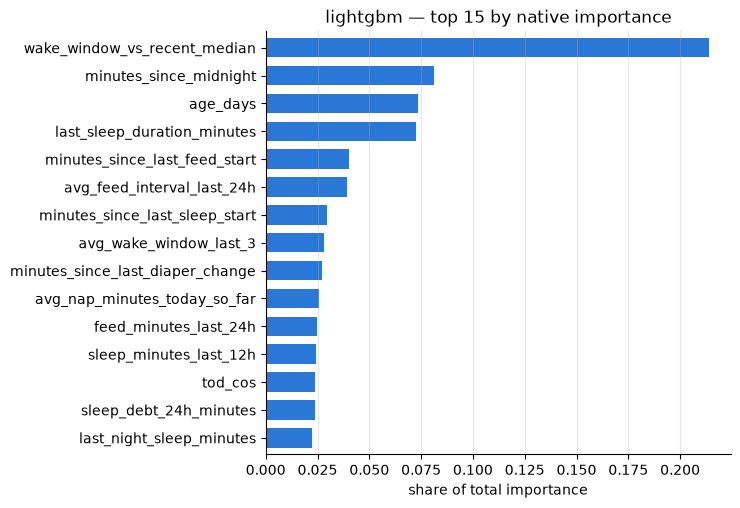

In [8]:
plot_feature_importance(model, top=15);

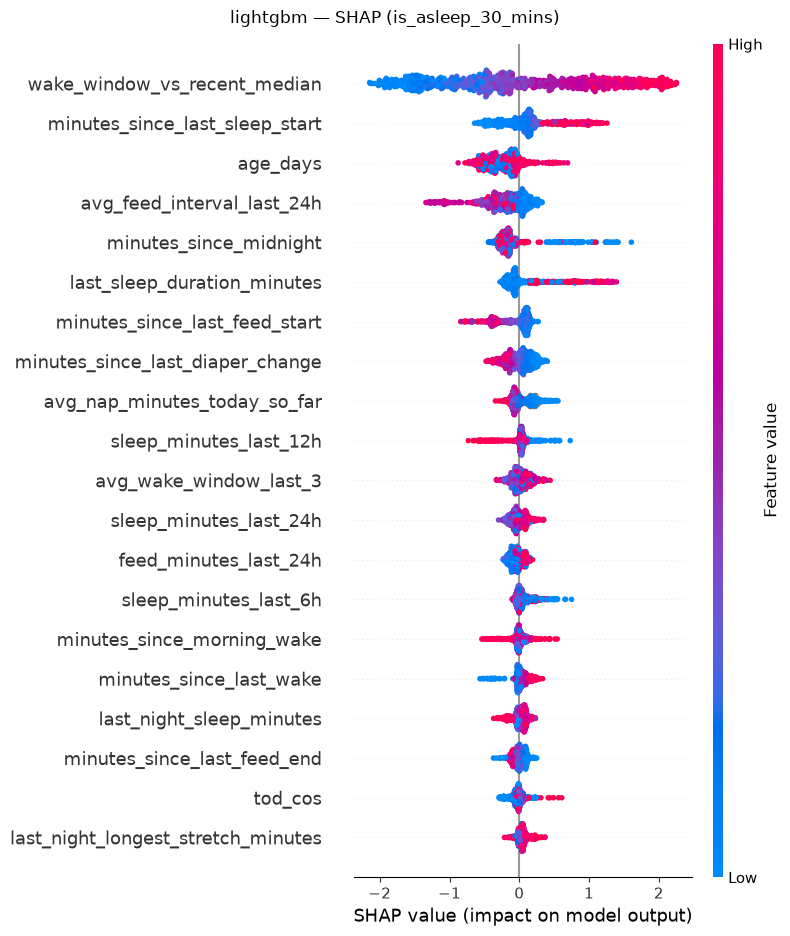

In [9]:
plot_shap_summary(model, X_val, max_display=20);

## Comparing LightGBM, XGBoost and random forest

`Comparison.run` trains all three kinds on both labels, each with the same features and split, then scores them on `val`. Colours are fixed per model across every chart.

SHAP is computed once per model on a 1,000-row sample and cached. The forest is the slow one, at around a minute per label.

In [10]:
comparison = Comparison.run(df, split="val")
comparison.metrics().round(3)

split  rows  base_rate  pr_auc  roc_auc  \
label             model                                                   
is_asleep_30_mins lightgbm        val  4390      0.222   0.567    0.850   
                  xgboost         val  4390      0.222   0.582    0.853   
                  random_forest   val  4390      0.222   0.520    0.838   
is_asleep_60_mins lightgbm        val  4390      0.426   0.774    0.865   
                  xgboost         val  4390      0.426   0.773    0.865   
                  random_forest   val  4390      0.426   0.761    0.859   

                                 brier  brier_base_rate  mean_predicted  
label             model                                                  
is_asleep_30_mins lightgbm       0.138            0.173           0.311  
                  xgboost        0.136            0.173           0.301  
                  random_forest  0.139            0.173           0.310  
is_asleep_60_mins lightgbm       0.162            0.245           0.545  
                  xgboost        0.163            0.245           0.548  
                  random_forest  0.165            0.245           0.534

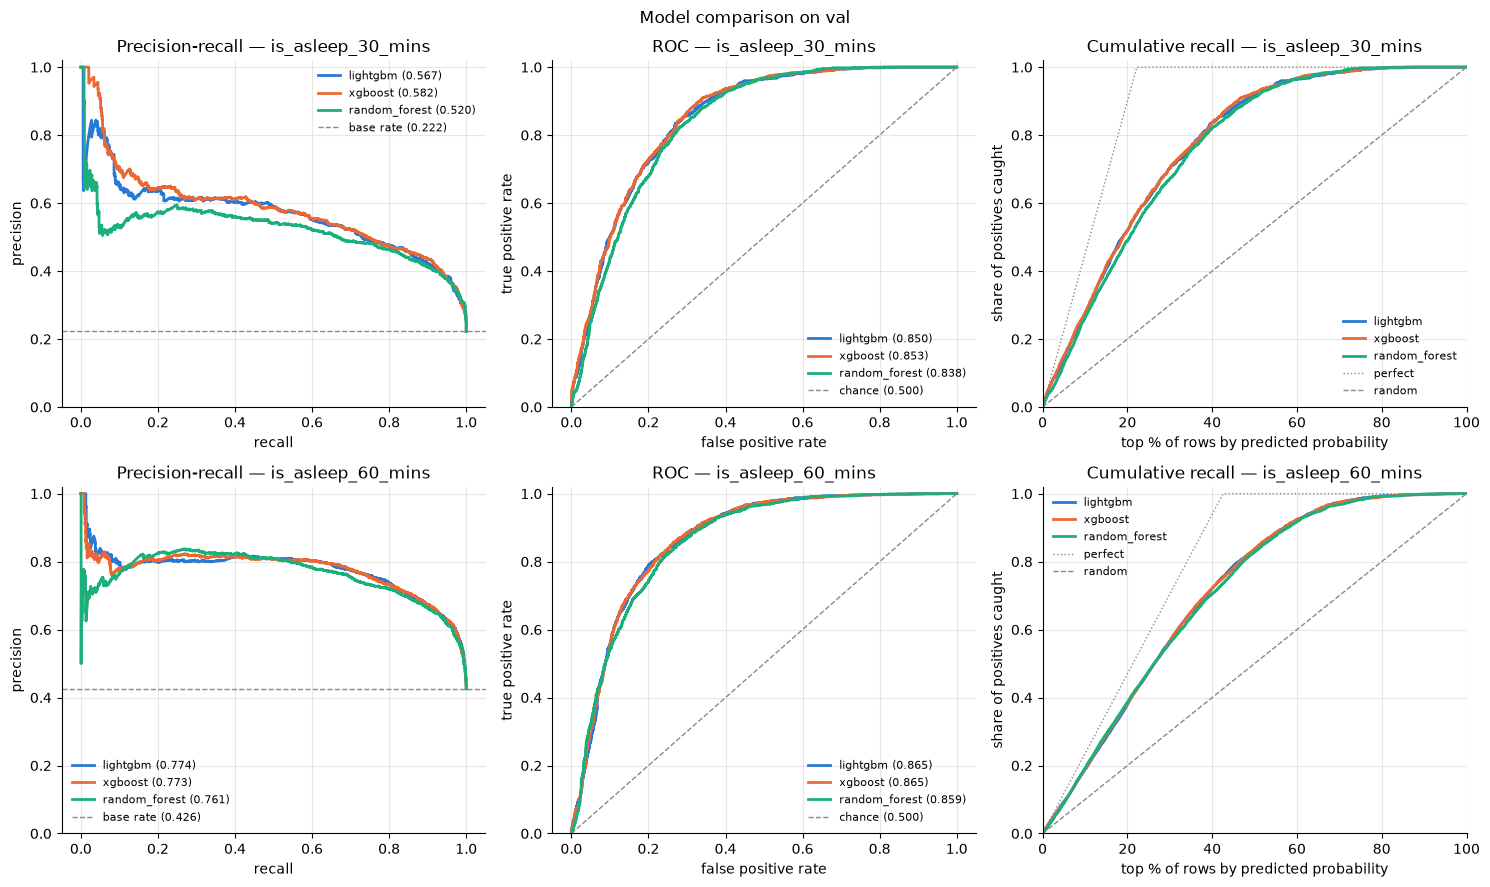

In [11]:
comparison.plot_performance();

In [12]:
comparison.recall_at_percentiles().round(3)

top 5%  top 10%  top 20%  top 30%  top 50%
label             model                                                    
is_asleep_30_mins lightgbm        0.137    0.275    0.519    0.703    0.921
                  xgboost         0.151    0.278    0.519    0.704    0.925
                  random_forest   0.124    0.263    0.488    0.671    0.912
is_asleep_60_mins lightgbm        0.094    0.189    0.379    0.567    0.836
                  xgboost         0.090    0.189    0.381    0.566    0.837
                  random_forest   0.088    0.193    0.387    0.560    0.828

### Which features each model relies on

Mean |SHAP|, normalised so each column sums to 1. The rows are the union of each model's top 15, so a feature that only one model leans on still shows up.

In [13]:
comparison.shap_importance(top=15).style.format("{:.3f}").background_gradient(cmap="Blues", axis=None)

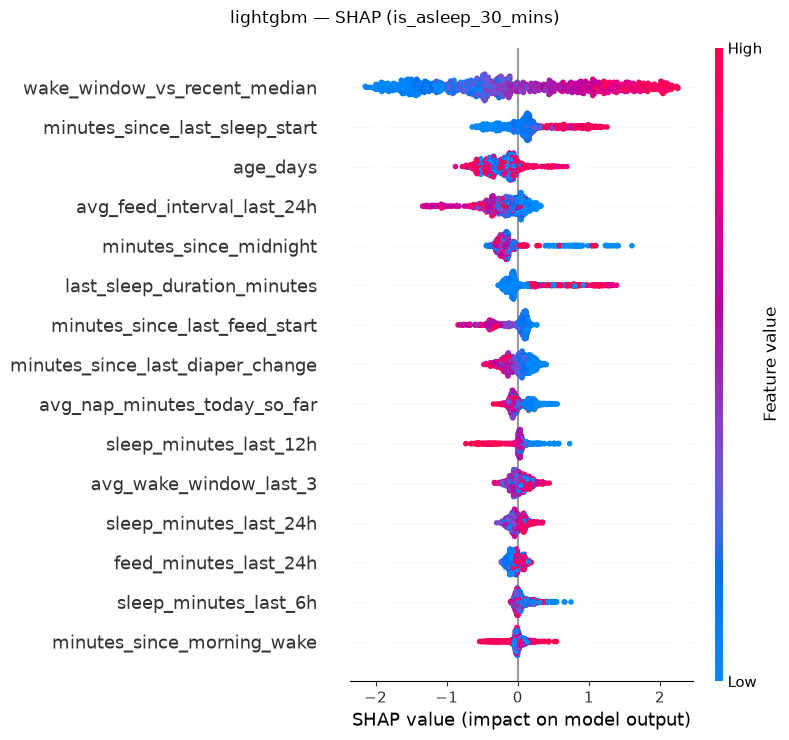

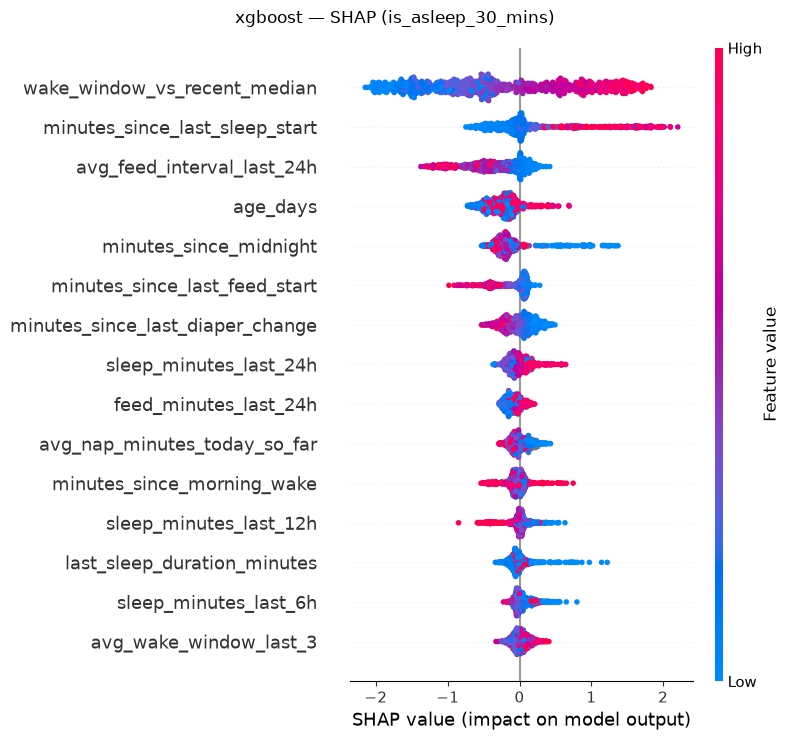

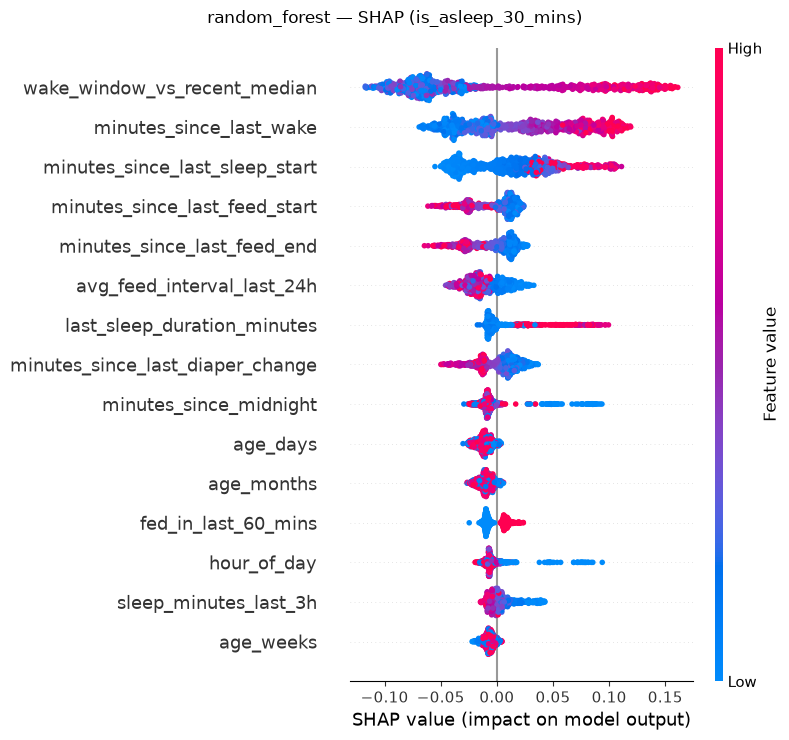

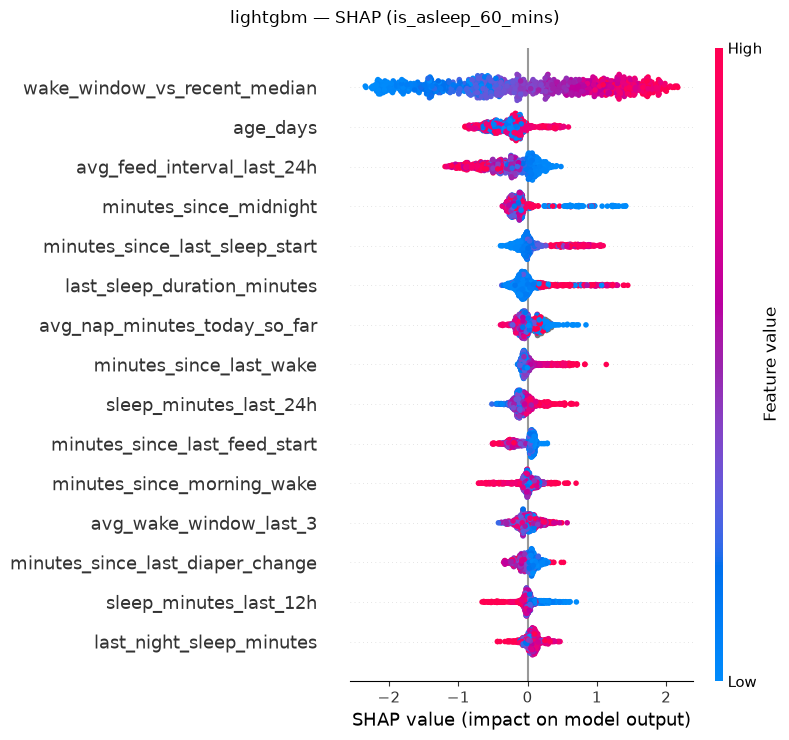

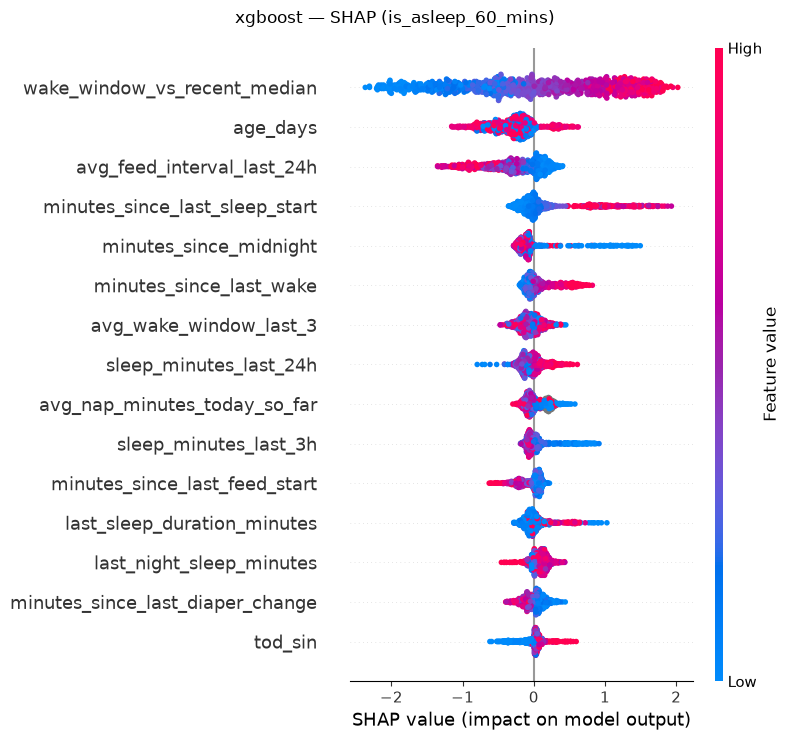

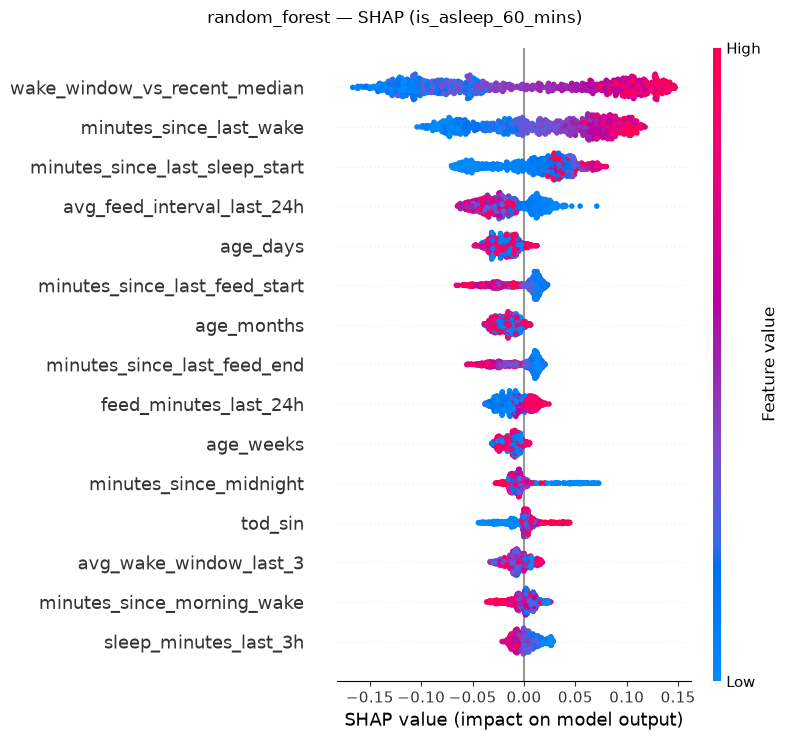

In [14]:
comparison.plot_shap_summaries(max_display=15);